# Density method - $\mu$ interpolation

## 1) Geometry

In [2]:
from ngsolve import *
from ngsolve.webgui import Draw
import ngsolve 
ngsolve.SetNumThreads(1)
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.animation as animation
import numpy as np
import imageio
import io

In [3]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 1e-2)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 2) Magnetostatic problem

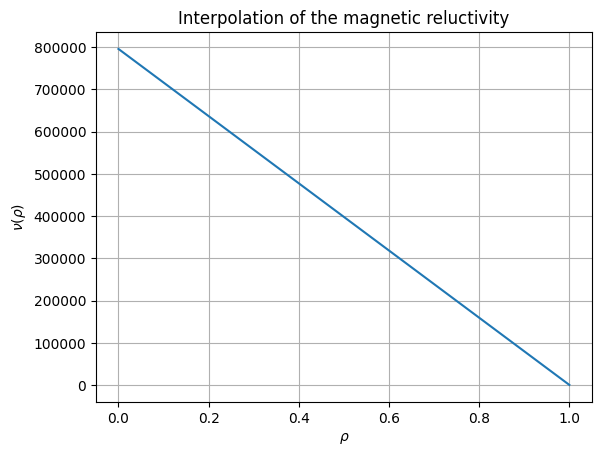

In [4]:
###############################################################################
## CODE CELL 2 : Define interpolation of the magnetic reluctivity
###############################################################################

from numpy import pi
mu0 = 4e-7 * pi   # magnetic permeability of air (H/m)
mur = 1000        # relative magnetic permeability of the iron    
p = 1

def nu(rho, p=1):
    """ reluctivity depending on the density """
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)  # power law interpolation of nu
    # return 1/ (mu0 + rho**p * (mur*mu0 -mu0))    # power law interpolation of mu

def dnu_drho(rho, p=1):
    """ Dérivée de nu par rapport à rho """
    return p * rho**(p-1) * (1/(mu0*mur) - 1/mu0)
    
# Plot the interpolation
import matplotlib.pyplot as plt
import numpy as np

rho = np.linspace(0,1,100)
plt.plot(rho, nu(rho,p)); plt.xlabel("$\\rho$"); 
plt.ylabel("$\\nu(\\rho)$"); plt.grid(); 
plt.title("Interpolation of the magnetic reluctivity")
plt.show()

In [5]:
###############################################################################
## CODE CELL 3 : Define the magnetostatic solver
###############################################################################

j = 1e6 # current density in the primary coil (A/m²)

from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

from ngsolve import H1, BilinearForm, LinearForm, dx
from utils.solver import solve

def state(rho):
    """ Solve the state equation for a given density field rho """
    fes = H1(mesh, order = 1, dirichlet = "dOmega")
    a, v = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)  
    lf = LinearForm(j * v * dx("Pp") - j * v * dx("Pm"))
    return solve(bf, lf)

# Test your function
a_rho, Kinv = state(0)
Draw(a_rho)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 3) Objective function & adjoint problem
### a) Objective function

In [6]:
from utils.solver import flux

# we want to maximize the secondary flux = minimize its opposite
def f(sol):
    return - flux(sol)

print(f" {f(a_rho) = :.5e} Wb/m")

 f(a_rho) = -9.67796e-04 Wb/m


### b) Adjoint problem

In [7]:
from ngsolve import dx

def df(a, rho, aStar):
    """ Directional derivative of the objective function in the direction aStar """
    return aStar*dx("Sm")  - aStar*dx("Sp")

from utils.optimization import solve_adjoint

p_rho = solve_adjoint(a_rho, rho,  Kinv, df )
Draw(p_rho)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 4) Material interpolation

Even if BESO is a ON-OFF method without intermediate materials, the computation of the derivative still depends on the derivative of the interpolation at $\rho = 0$ and $\rho = 1$.

## 5) Gradient of objective function w.r.t $\rho$

In [8]:
###############################################################################
## CODE CELL 6 : Directional derivative
############################################################################### 

from ngsolve import LinearForm
from utils.solver import curl

def f_prime(state, adjoint, rho):
    """ directional derivative of the objective function """
    fes = rho.space
    drho = fes.TestFunction()
    f_prime = LinearForm(fes)
    f_prime += curl(adjoint) * ( nu(rho).Diff(rho) * curl(state) ) * drho * dx  # directional derivative
    f_prime.Assemble()
    return f_prime  # return the linear form

# Test your function
from ngsolve import L2, GridFunction
rho = GridFunction(L2(mesh, definedon = "Omega_c"))
F_prime = GridFunction(rho.space)
F_prime.vec.data = f_prime(a_rho, p_rho, rho).vec
Draw(F_prime)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [9]:
###############################################################################
## CODE CELL 7 : Compute the derivative
############################################################################### 

def f_derivative(a_rho, rho, Kinv):
    """ Encapsulate derivative computation """
    v_rho = solve_adjoint(a_rho, rho, Kinv, df)
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = f_prime(a_rho, v_rho, rho).vec
    return riesz_representer

# Test the function
Draw(f_derivative(a_rho, rho, Kinv))

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 6) Volume

In [10]:
###############################################################################
## CODE CELL 10 : Unconstrained optimization algorithm
############################################################################### 

from ngsolve import Integrate
def m(rho, zone = "Omega_c"):
    """ mass function """
    return Integrate(rho*dx(zone), mesh)/Integrate(1, mesh, definedon = mesh.Materials(zone))

def m_prime(rho, zone = "Omega_c"):
    """ directional derivative of the mass function """
    fes = rho.space
    drho = fes.TestFunction()
    mprime = LinearForm(fes)
    mprime += drho * dx(zone)  # directional derivative
    mprime.Assemble()
    return mprime  # return the linear form

def m_derivative(rho):
    """ Encapsulate mass derivative computation """
    riesz_representer = GridFunction(rho.space)
    riesz_representer.vec.data = m_prime(rho).vec
    return riesz_representer

# Test the function
Draw(m_derivative(rho))  # we see the area of each triangle!

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 7) Optimization - BESO update

### Reference
> Querin, O.M., Young, V., Steven, G.P., Xie, Y.M. (2000).  
> *Computational efficiency and validation of bi-directional evolutionary structural optimisation.*  
> Comput. Methods Appl. Mech. Engrg. 189, 559–573



The algorithm follows the steps of Fig. 1 oin the paper:

1. Solve the finite element problem → state $u$
2. Compute the sensitivity criterion per element
3. **Remove** elements with sensitivity < low threshold (`RR × max`)
4. **Add** elements with sensitivity > high threshold (`IR × max`)
5. Check the volume constraint
6. Repeat until convergence



### Parameters (Eq. 4 and 5 of the paper)

The **rejection ratio** $RR$ and the **inclusion ratio** $IR$ evolve as:
$$RR = r_0 + r_1 \cdot SS + a_{RR} \cdot ON \quad (r_0=0,\ r_1=0.001,\ a_{RR}=0.01)$$
$$IR = i_0 - i_1 \cdot SS - a_{IR} \cdot ON \quad (i_0=1,\ i_1=0.01,\ a_{IR}=0.1)$$

In our implementation, these ratios are replaced by:
- `add_precision` and `remove_precision`: percentage of elements to modify per iteration
- `surf_ratio`: target volume constraint
- `init_factor`: correction factor (analogue of $ON$ to avoid oscillations)

> *"An oscillatory state occurs when an element is added in an iteration and the same element  
> is removed in the subsequent iteration"* — Querin et al., Section 2, rule (11)  


[0. 1. 1.]
N_triangles      = 7748
 It.:    1 | 77 ajouts, 62 suppressions | Objectif: 4.1717 | Surface: 1.13%
 It.:    2 | 69 ajouts, 55 suppressions | Objectif: 4.5321 | Surface: 1.34%
 It.:    3 | 67 ajouts, 54 suppressions | Objectif: 8.5216 | Surface: 1.51%
 It.:    4 | 66 ajouts, 53 suppressions | Objectif: 15.8023 | Surface: 1.68%
 It.:    5 | 64 ajouts, 52 suppressions | Objectif: 32.4137 | Surface: 1.83%
 It.:    6 | 63 ajouts, 51 suppressions | Objectif: 72.5061 | Surface: 2.01%
 It.:    7 | 62 ajouts, 50 suppressions | Objectif: 101.2959 | Surface: 2.18%
 It.:    8 | 61 ajouts, 48 suppressions | Objectif: 263.9501 | Surface: 2.40%
 It.:    9 | 59 ajouts, 47 suppressions | Objectif: 1282.2854 | Surface: 2.53%
 It.:   10 | 58 ajouts, 46 suppressions | Objectif: 1859.6659 | Surface: 2.71%
 It.:   11 | 56 ajouts, 45 suppressions | Objectif: 2115.4532 | Surface: 2.84%
 It.:   12 | 55 ajouts, 44 suppressions | Objectif: 2264.0329 | Surface: 3.03%
 It.:   13 | 54 ajouts, 43 suppres

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

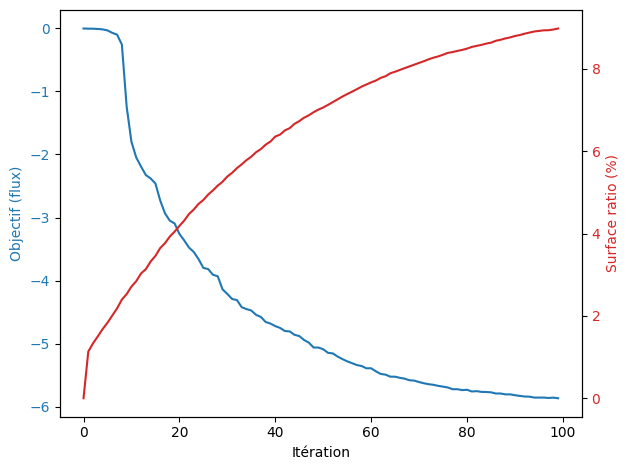

In [16]:
###############################################################################
## CODE CELL BESO : Optimization loop
###############################################################################
from ngsolve import L2, GridFunction, Integrate
import numpy as np

# ── Masque Omega_c et volumes élémentaires ────────────────────────────
V0 = Integrate(1, mesh, definedon=mesh.Materials("Omega_c"))
# mask_gf = GridFunction(L2(mesh, definedon=mesh.Materials("Omega_c")))
# mhh
mask_gf = GridFunction(L2(mesh))
mask_gf.Set(mesh.MaterialCF({"Omega_c": 1}))
vals = mask_gf.vec.FV().NumPy()[:]
print(np.unique(vals))

maskOmega_c = mask_gf.vec.FV().NumPy()[:] > 0.5
#mask_gf.Set(1)
#maskOmega_c = mask_gf.vec.FV().NumPy()[:] == 1   # bool, taille maillage complet
N_triangles  = int(np.sum(maskOmega_c))
eVol = Integrate(1, mesh, definedon=mesh.Materials("Omega_c"),
                element_wise=True).NumPy()[maskOmega_c] / V0   # taille N_triangles
# eVol = Integrate(1, mesh, element_wise=True).NumPy()[maskOmega_c] / V0

print(f"N_triangles      = {N_triangles}")

# ── Fonction sensitivité ──────────────────────────────────────────────
def compute_sensitivity(rho):
    u, Kinv = state(rho)
    obj = f(u)
    sens = - f_derivative(u, rho, Kinv).vec.FV().NumPy()[maskOmega_c]  # taille N_triangles
 #   p_adj = solve_adjoint(u, rho, Kinv, df)
    
  #  sens = -Integrate(
   #     dnu_drho(rho) * grad(u) * grad(p_adj),
    #    mesh, element_wise=True
    #).NumPy()[maskOmega_c]
    

    return sens, obj

# ── Initialisation rho = 0 (tout air) ────────────────────────────────
rho = GridFunction(L2(mesh, definedon="Omega_c"))
# rho = GridFunction(L2(mesh))
xval         = np.zeros(N_triangles)
modified     = list(range(N_triangles))
current_surf = 0.0
loop         = 0

sens, obj   = compute_sensitivity(rho)
initial_obj = obj
max_surf    = np.sum(eVol)

# ── Paramètres BESO ───────────────────────────────────────────────────
surf_ratio       = 0.1
surf_precision   = 0.999
add_precision    = 0.01
remove_precision = 0.01
init_factor      = 0.8
N_max            = 100

MemObjective  = []
MemConstraint = []

# ── Boucle BESO ───────────────────────────────────────────────────────
while ((current_surf < max_surf * surf_ratio * surf_precision or
        current_surf > max_surf * surf_ratio) and loop < N_max):

    MemObjective.append(obj)
    MemConstraint.append(current_surf / max_surf)
    loop += 1

    ratio = abs(current_surf / max_surf / surf_ratio - 1.0)

    if current_surf > max_surf * surf_ratio:
        init_factor    = 1.1
        surf_precision -= 0.1
    if (current_surf < max_surf * surf_ratio * surf_precision
            and init_factor == 1.1):
        init_factor    = 0.9
        surf_precision -= 0.1

    add_nbr    = round(add_precision    * ratio * N_triangles)
    remove_nbr = round(remove_precision * init_factor * ratio * N_triangles)

    if add_nbr == remove_nbr:
        if current_surf > max_surf * surf_ratio:
            remove_nbr += 1
        else:
            add_nbr += 1

    # Sélection vectorisée avec anti-oscillation
    modified_mask = np.zeros(N_triangles, dtype=bool)
    modified_mask[modified] = True

    candidates_add    = np.where( modified_mask)[0]
    candidates_remove = np.where(~modified_mask)[0]

    if add_nbr > 0 and len(candidates_add) > 0:
        n = min(add_nbr, len(candidates_add))
        top_add = candidates_add[np.argsort(sens[candidates_add])[-n:]]
        xval[top_add] = 1.0
        modified_mask[top_add] = False

    if remove_nbr > 0 and len(candidates_remove) > 0:
        n = min(remove_nbr, len(candidates_remove))
        top_remove = candidates_remove[np.argsort(sens[candidates_remove])[:n]]
        xval[top_remove] = 0.0
        modified_mask[top_remove] = True

    modified = list(np.where(modified_mask)[0])

    # Mise à jour de rho (.NumPy() retourne une copie, il faut passer par FV)
    tmp = rho.vec.FV().NumPy().copy()
    tmp[maskOmega_c] = xval
    rho.vec.FV()[:] = tmp

    # Recalcul EF
    sens, obj    = compute_sensitivity(rho)
    current_surf = np.sum(eVol * xval)

    print(f" It.: {loop:4d}"
          f" | {add_nbr} ajouts, {remove_nbr} suppressions"
          f" | Objectif: {obj / initial_obj:.4f}"
          f" | Surface: {current_surf / max_surf * 100:.2f}%")

# ── Résultats finaux ──────────────────────────────────────────────────
u, _ = state(rho)
print(f"Résultats BESO : flux = {flux(u):.5e} | vol = {m(rho)*100:.3f}% | itérations = {loop}")
Draw(rho, mesh, settings={"Objects": {"Wireframe": False}})

fig, ax1 = plt.subplots()
ax1.plot(MemObjective, color="tab:blue")
ax1.set_xlabel("Itération")
ax1.set_ylabel("Objectif (flux)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot([s * 100 for s in MemConstraint], color="tab:red")
ax2.set_ylabel("Surface ratio (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
fig.tight_layout()
plt.show()


## 8) Analysis of the results

### a) Quantities of interest

In [12]:
u, _ = state(rho)
print(f"Results BESO : flux = {flux(u):.5e} | vol = {m(rho)*100:.3f}% | iterations = {loop}")


Results BESO : flux = 2.56090e+00 | vol = 7.706% | iterations = 100
